Ejercicio de evaluación final Módulo 3.

Fase 1: Exploración y Limpieza

In [32]:
# importamos las librerías que necesitamos
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

from src import soporte_exploracion as se
from src import soporte_limpieza as sl

In [33]:
df_ac = pd.read_csv("files/Customer Flight Activity.csv") # cargamos el dataset en un DataFrame llamado df_ac

In [34]:
df_hi = pd.read_csv("files/Customer Loyalty History.csv") # cargamos el dataset en un DataFrame llamado df_hi

In [35]:
df_ac.head()# para visualizar las primeras filas del DataFrame df_ac

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0
2,100140,2017,1,6,0,6,1200,120.0,0,0
3,100214,2017,1,0,0,0,0,0.0,0,0
4,100272,2017,1,0,0,0,0,0.0,0,0


In [36]:
df_hi.head() # para visualizar las primeras filas del DataFrame df_hi

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


In [37]:
df_ac.shape # para conocer el número de filas y columnas del DataFrame df_ac

(405624, 10)

In [38]:
df_hi.shape # para conocer el número de filas y columnas del DataFrame df_hi

(16737, 16)

In [39]:
se.analizar_dataframe(df_ac)# para analizar el DataFrame df_ac

ANÁLISIS DEL DATAFRAME (405624 filas, 10 columnas)

Columna: Loyalty Number
  - Tipo de dato: int64
  - Nulos: 0 (0.0%)
  - Valores únicos: [100018 100102 100140 ... 999731 999788 999891]
  - Número de valores únicos: 16737
Columna: Year
  - Tipo de dato: int64
  - Nulos: 0 (0.0%)
  - Valores únicos: [2017 2018]
  - Número de valores únicos: 2
Columna: Month
  - Tipo de dato: int64
  - Nulos: 0 (0.0%)
  - Valores únicos: [ 1  9  2  3 11  4  5  7  6  8 10 12]
  - Número de valores únicos: 12
Columna: Flights Booked
  - Tipo de dato: int64
  - Nulos: 0 (0.0%)
  - Valores únicos: [ 3 10  6  0  8 11  9  4  7  5  2  1 12 13 14 16 15 17 18 19 20 21]
  - Número de valores únicos: 22
Columna: Flights with Companions
  - Tipo de dato: int64
  - Nulos: 0 (0.0%)
  - Valores únicos: [ 0  4  7  1  6  3  5  2 10  8  9 11]
  - Número de valores únicos: 12
Columna: Total Flights
  - Tipo de dato: int64
  - Nulos: 0 (0.0%)
  - Valores únicos: [ 3 14  6  0 15 11 12 10  8  9  7  5 16  2  1 17 13 22  4 19

In [40]:
se.analizar_dataframe(df_hi) # para analizar el DataFrame df_hi

ANÁLISIS DEL DATAFRAME (16737 filas, 16 columnas)

Columna: Loyalty Number
  - Tipo de dato: int64
  - Nulos: 0 (0.0%)
  - Valores únicos: [480934 549612 429460 ... 776187 906428 652627]
  - Número de valores únicos: 16737
Columna: Country
  - Tipo de dato: str
  - Nulos: 0 (0.0%)
  - Valores únicos: <StringArray>
['Canada']
Length: 1, dtype: str
  - Número de valores únicos: 1
Columna: Province
  - Tipo de dato: str
  - Nulos: 0 (0.0%)
  - Valores únicos: <StringArray>
[             'Ontario',              'Alberta',     'British Columbia',
               'Quebec',                'Yukon',        'New Brunswick',
             'Manitoba',          'Nova Scotia',         'Saskatchewan',
         'Newfoundland', 'Prince Edward Island']
Length: 11, dtype: str
  - Número de valores únicos: 11
Columna: City
  - Tipo de dato: str
  - Nulos: 0 (0.0%)
  - Valores únicos: <StringArray>
[       'Toronto',       'Edmonton',      'Vancouver',           'Hull',
     'Whitehorse',        'Trenton',  

In [41]:
df_ac.duplicated().sum() # para comprobar si hay filas duplicadas en el DataFrame df_ac

np.int64(1864)

In [42]:
df_hi.duplicated().sum() # para comprobar si hay filas duplicadas en el DataFrame df_hi

np.int64(0)

In [43]:
df_ac[df_ac.duplicated(keep=False)].value_counts() # para visualizar las filas duplicadas en el DataFrame df_ac y conocer cuántas veces se repite cada una de ellas

Loyalty Number  Year  Month  Flights Booked  Flights with Companions  Total Flights  Distance  Points Accumulated  Points Redeemed  Dollar Cost Points Redeemed
678205          2017  1      0               0                        0              0         0.0                 0                0                              3
                      2      0               0                        0              0         0.0                 0                0                              3
                      3      0               0                        0              0         0.0                 0                0                              3
                      4      0               0                        0              0         0.0                 0                0                              3
                      5      0               0                        0              0         0.0                 0                0                              3
               

In [44]:
df_ac = df_ac.drop_duplicates() # para eliminar las filas duplicadas del DataFrame df_ac y asignar el resultado al mismo DataFrame df_ac

In [45]:
df_ac.duplicated().sum() # para comprobar si hay filas duplicadas en el DataFrame df_ac

np.int64(0)

In [46]:
df = pd.merge(df_hi, df_ac, on='Loyalty Number', how='left') # para fusionar los DataFrames df_hi y df_ac utilizando la columna 'Loyalty Number' como clave de unión y asignar el resultado a un nuevo DataFrame llamado df

In [47]:
df.head()  # para visualizar las primeras filas del DataFrame df

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,1,0,0,0,0,0.0,0,0
1,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,2,3,0,3,2823,282.0,0,0
2,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,3,0,0,0,0,0.0,0,0
3,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,4,0,0,0,0,0.0,0,0
4,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2018,10,6,2,8,3352,335.0,465,38


In [48]:
df.shape # para conocer el número de filas y columnas del DataFrame df

(403760, 25)

In [49]:
df.duplicated().sum() # para comprobar si hay filas duplicadas en el DataFrame df

np.int64(0)

In [50]:
df.info() # para obtener información sobre el DataFrame df, incluyendo el número de filas, columnas, tipos de datos y cantidad de valores no nulos en cada columna

<class 'pandas.DataFrame'>
RangeIndex: 403760 entries, 0 to 403759
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               403760 non-null  int64  
 1   Country                      403760 non-null  str    
 2   Province                     403760 non-null  str    
 3   City                         403760 non-null  str    
 4   Postal Code                  403760 non-null  str    
 5   Gender                       403760 non-null  str    
 6   Education                    403760 non-null  str    
 7   Salary                       301500 non-null  float64
 8   Marital Status               403760 non-null  str    
 9   Loyalty Card                 403760 non-null  str    
 10  CLV                          403760 non-null  float64
 11  Enrollment Type              403760 non-null  str    
 12  Enrollment Year              403760 non-null  int64  
 13  Enrollment

In [51]:
df.describe().T # para comprobar que ya no hay nulos en Salary y que el valor imputado es el correcto

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,403760.0,549875.383713,258961.514684,100018.00,326699.00,550598.00,772152.00,999986.00
Salary,301500.0,79258.576285,34983.929798,-58486.00,59262.00,73479.00,88606.00,407228.00
CLV,403760.0,7990.864857,6863.317160,1898.01,3981.78,5776.34,8937.12,83325.38
Enrollment Year,403760.0,2015.250716,1.979427,2012.00,2014.00,2015.00,2017.00,2018.00
Enrollment Month,403760.0,6.667555,3.398829,1.00,4.00,7.00,10.00,12.00
Cancellation Year,49650.0,2016.504350,1.380482,2013.00,2016.00,2017.00,2018.00,2018.00
Cancellation Month,49650.0,6.962095,3.454362,1.00,4.00,7.00,10.00,12.00
Year,403760.0,2017.500352,0.500000,2017.00,2017.00,2018.00,2018.00,2018.00
Month,403760.0,6.501335,3.451982,1.00,4.00,7.00,10.00,12.00
Flights Booked,403760.0,4.134050,5.230064,0.00,0.00,1.00,8.00,21.00


In [52]:
df.describe(include=["str"]).T # para obtener estadísticas descriptivas de las columnas de tipo string del DataFrame df, incluyendo el número de valores únicos, el valor más frecuente y su frecuencia, y mostrar el resultado transpuesto para una mejor visualización

,count,unique,top,freq
Country,403760,1,Canada,403760
Province,403760,11,Ontario,130258
City,403760,29,Toronto,80775
Postal Code,403760,55,V6E 3D9,21944
Gender,403760,2,Female,202757
Education,403760,5,Bachelor,252567
Marital Status,403760,3,Married,234845
Loyalty Card,403760,3,Star,183745
Enrollment Type,403760,2,Standard,380419


In [53]:
educacion_salario = df.groupby("Education")["Salary"].agg(["median", "mean", "max", "min"]) # para agrupar el DataFrame df por la columna "Education" y calcular la mediana, media, máximo y mínimo de la columna "Salary" para cada grupo, y asignar el resultado a un nuevo DataFrame llamado educacion_salario

In [54]:
educacion_salario.sort_values(by="max", ascending=False) # para visualizar el DataFrame educacion_salario, que contiene la mediana, media, máximo y mínimo de la columna "Salary" para cada grupo de la columna "Education" del DataFrame df

,median,mean,max,min
Education,,,,
Doctor,180440.0,178403.675202,407228.0,48109.0
Master,105487.0,103734.523724,133080.0,56414.0
Bachelor,71972.0,72473.471154,105563.0,-58486.0
High School or Below,61806.0,61019.926143,93875.0,-49830.0
College,NaN,NaN,NaN,NaN


<Axes: xlabel='Salary'>

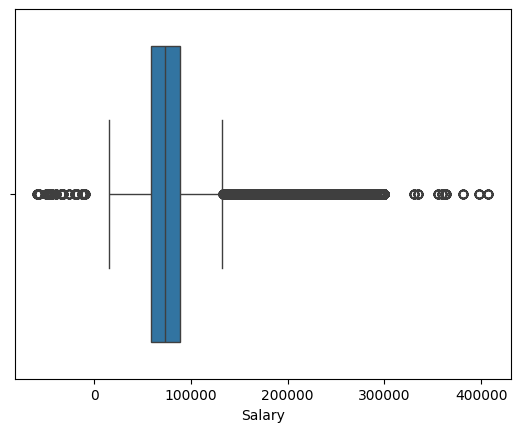

In [55]:
sns.boxplot(data = df, x="Salary") # para crear un diagrama de caja (boxplot) de la columna "Salary" del DataFrame df, lo que puede ayudar a visualizar la distribución de los salarios y a identificar posibles valores atípicos o extremos en esa variable.

In [62]:
df["Salary"] = df["Salary"].abs() # para convertir los valores de la columna "Salary" del DataFrame df a sus valores absolutos, lo que eliminará cualquier valor negativo y asignar el resultado a la misma columna "Salary" del DataFrame df


negativos = (df['Salary'] < 0).sum()

negativos

np.int64(0)

In [63]:
# Calculamos la media de Bachelor
media_bachelor = df.loc[df["Education"] == "Bachelor", "Salary"].mean()

# Calculamos la media de High School or Below
media_high_school = df.loc[df["Education"] == "High School or Below", "Salary"].mean()

# Calculamos la media de ambos
media_bachelor_high_school = (media_bachelor + media_high_school) / 2

# Imputamos el valor calculado para College
media_bachelor_high_school

np.float64(66872.72953933029)

In [64]:
# Rellenamos los nulos de Salary donde la educación es College
df.loc[df["Education"] == "College", "Salary"] = df["Salary"].fillna(media_bachelor_high_school)

In [65]:
df.describe().T # para comprobar que ya no hay nulos en Salary y que el valor imputado es el correcto

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,403760.0,549875.383713,258961.514684,100018.00,326699.00,550598.00,772152.00,999986.00
Salary,403760.0,76174.022761,30506.537333,9081.00,63901.00,66746.00,82940.00,407228.00
CLV,403760.0,7990.864857,6863.317160,1898.01,3981.78,5776.34,8937.12,83325.38
Enrollment Year,403760.0,2015.250716,1.979427,2012.00,2014.00,2015.00,2017.00,2018.00
Enrollment Month,403760.0,6.667555,3.398829,1.00,4.00,7.00,10.00,12.00
Cancellation Year,49650.0,2016.504350,1.380482,2013.00,2016.00,2017.00,2018.00,2018.00
Cancellation Month,49650.0,6.962095,3.454362,1.00,4.00,7.00,10.00,12.00
Year,403760.0,2017.500352,0.500000,2017.00,2017.00,2018.00,2018.00,2018.00
Month,403760.0,6.501335,3.451982,1.00,4.00,7.00,10.00,12.00
Flights Booked,403760.0,4.134050,5.230064,0.00,0.00,1.00,8.00,21.00


In [66]:
df.isna().sum() # comprobamos que ya no hay nulos en Salary

Loyalty Number                      0
Country                             0
Province                            0
City                                0
Postal Code                         0
Gender                              0
Education                           0
Salary                              0
Marital Status                      0
Loyalty Card                        0
CLV                                 0
Enrollment Type                     0
Enrollment Year                     0
Enrollment Month                    0
Cancellation Year              354110
Cancellation Month             354110
Year                                0
Month                               0
Flights Booked                      0
Flights with Companions             0
Total Flights                       0
Distance                            0
Points Accumulated                  0
Points Redeemed                     0
Dollar Cost Points Redeemed         0
dtype: int64

In [67]:
df["Salary"] = df["Salary"].astype(int) # para convertir los valores de la columna "Salary" del DataFrame df a enteros, lo que puede ser útil para facilitar el análisis y la visualización de los datos relacionados con los salarios.

In [68]:
df['status'] = np.where(df['Cancellation Year'].isna(), 'active', 'inactive') # para crear una nueva columna llamada "status" en el DataFrame df, donde se asigna el valor 'active' si la columna 'Cancellation Year' es nula (es decir, si el cliente no ha cancelado su membresía) y se asigna el valor 'inactive' si la columna 'Cancellation Year' no es nula (es decir, si el cliente ha cancelado su membresía).

In [80]:
sl.limpiar_columnas(df) # para limpiar los nombres de las columnas del DataFrame df, eliminando espacios en blanco, caracteres especiales y convirtiendo los nombres a minúsculas, lo que puede facilitar el acceso a las columnas y mejorar la legibilidad del código.

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,status
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,1,0,0,0,0,0.0,0,0,active
1,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,2,3,0,3,2823,282.0,0,0,active
2,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,3,0,0,0,0,0.0,0,0,active
3,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,4,0,0,0,0,0.0,0,0,active
4,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2018,10,6,2,8,3352,335.0,465,38,active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403755,652627,Canada,Manitoba,Winnipeg,R2C 0M5,Female,Bachelor,75049,Married,Star,83325.38,Standard,2015,12,2016.0,8.0,2018,8,0,0,0,0,0.0,0,0,inactive
403756,652627,Canada,Manitoba,Winnipeg,R2C 0M5,Female,Bachelor,75049,Married,Star,83325.38,Standard,2015,12,2016.0,8.0,2018,9,0,0,0,0,0.0,0,0,inactive
403757,652627,Canada,Manitoba,Winnipeg,R2C 0M5,Female,Bachelor,75049,Married,Star,83325.38,Standard,2015,12,2016.0,8.0,2018,10,0,0,0,0,0.0,0,0,inactive
403758,652627,Canada,Manitoba,Winnipeg,R2C 0M5,Female,Bachelor,75049,Married,Star,83325.38,Standard,2015,12,2016.0,8.0,2018,11,0,0,0,0,0.0,0,0,inactive


In [81]:
df = df.drop(columns="country") # para eliminar la columna "country" del DataFrame df, lo que puede ser útil si esa columna no es relevante para el análisis o si contiene datos que no aportan valor al conjunto de datos.

In [82]:
df.head(2)

,loyalty_number,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,status
0,480934,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,1,0,0,0,0,0.0,0,0,active
1,480934,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,2,3,0,3,2823,282.0,0,0,active


In [ ]:
df.to_csv("customer_flight_activity_limpio.csv", index=False) # para guardar el DataFrame df en un archivo CSV llamado "customer_flight_activity_limpio.csv" sin incluir el índice de las filas, lo que puede ser útil para compartir o utilizar el conjunto de datos limpio en otros contextos o herramientas de análisis.